# Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스

# Load data

In [19]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
file_list = glob.glob(os.path.join(path, '20*.csv'))

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        # 1. UTF-8으로 먼저 읽기를 시도합니다.
        # 2. DtypeWarning을 해결하기 위해 low_memory=False 옵션을 추가합니다.
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        #print(f"  [성공] '{os.path.basename(file)}' 파일을 'utf-8'로 읽었습니다.")
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        # 만약 UTF-8 읽기에 실패하면(UnicodeDecodeError 발생), cp949로 다시 시도합니다.
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            #print(f"  [성공] '{os.path.basename(file)}' 파일을 'cp949'로 읽었습니다.")
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행합니다.
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 7
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (3557756, 23)


# Data Structure

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557756 entries, 0 to 3557755
Data columns (total 23 columns):
 #   Column   Dtype  
---  ------   -----  
 0   접수년도     int64  
 1   자치구코드    int64  
 2   자치구명     object 
 3   법정동코드    int64  
 4   법정동명     object 
 5   지번구분코드   float64
 6   지번구분     object 
 7   본번       float64
 8   부번       float64
 9   층        float64
 10  계약일      int64  
 11  전월세구분    object 
 12  임대면적     float64
 13  보증금(만원)  int64  
 14  임대료(만원)  int64  
 15  건물명      object 
 16  건축년도     float64
 17  건물용도     object 
 18  계약기간     object 
 19  신규계약구분   object 
 20  갱신청구권사용  object 
 21  종전보증금    float64
 22  종전임대료    float64
dtypes: float64(8), int64(6), object(9)
memory usage: 624.3+ MB


In [21]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료'],
      dtype='object')


In [22]:
print(df.head(5))

   접수년도  자치구코드 자치구명  법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
0  2020  11170  용산구  11300  원효로2가     1.0   대지     1.0   0.0   6.0  ...   
1  2020  11440  마포구  11000   노고산동     1.0   대지     1.0   1.0   9.0  ...   
2  2020  11440  마포구  11000   노고산동     1.0   대지     1.0   1.0  10.0  ...   
3  2020  11590  동작구  10700    사당동     1.0   대지  1007.0  19.0   7.0  ...   
4  2020  11590  동작구  10700    사당동     1.0   대지  1007.0  19.0   3.0  ...   

   보증금(만원) 임대료(만원)            건물명    건축년도  건물용도 계약기간  신규계약구분 갱신청구권사용 종전보증금  \
0     5000       0        \t(1)\t  1990.0  오피스텔  NaN     NaN     NaN   NaN   
1    18500       0      \t(1-1)\t  1998.0  오피스텔  NaN     NaN     NaN   NaN   
2    22000       0      \t(1-1)\t  1998.0  오피스텔  NaN     NaN     NaN   NaN   
3      500      24  \t(1007-19)\t  2002.0  오피스텔  NaN     NaN     NaN   NaN   
4    17325       0  \t(1007-19)\t  2002.0  오피스텔  NaN     NaN     NaN   NaN   

  종전임대료  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  

[5 rows x 23 column

# Data Cleaning & Preparation

In [23]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
print(df.head(3))

   접수년도 자치구명   법정동명 전월세구분   임대면적  보증금(만원)  임대료(만원)  건물용도
0  2020  용산구  원효로2가    전세  22.03     5000        0  오피스텔
1  2020  마포구   노고산동    전세  33.66    18500        0  오피스텔
2  2020  마포구   노고산동    전세  41.04    22000        0  오피스텔


In [59]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [24]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도       0
자치구명       0
법정동명       0
전월세구분      9
임대면적       0
보증금(만원)    0
임대료(만원)    0
건물용도       0
dtype: int64


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

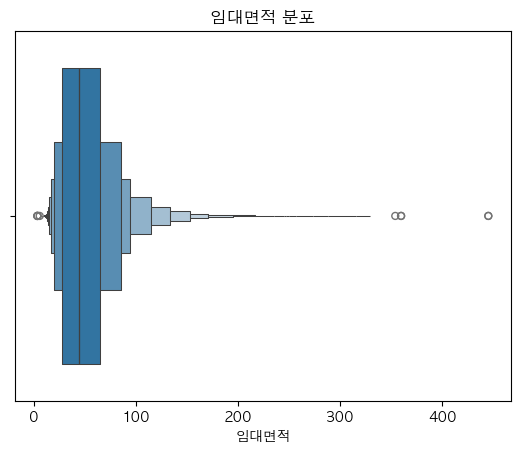

In [25]:
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

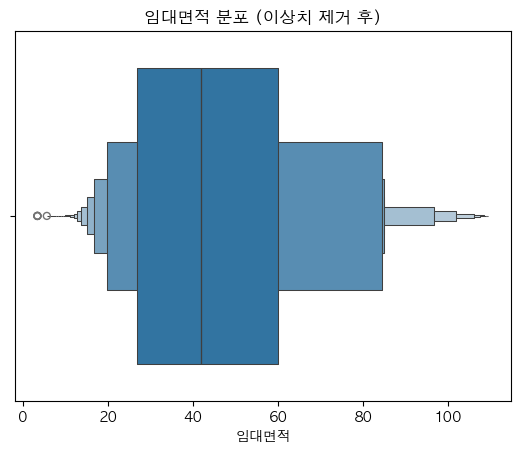

In [27]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


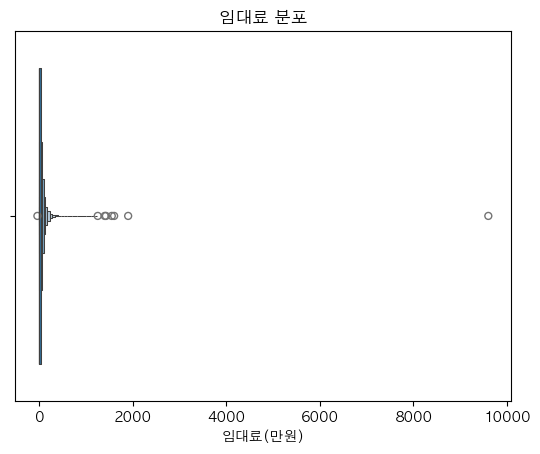

In [28]:
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

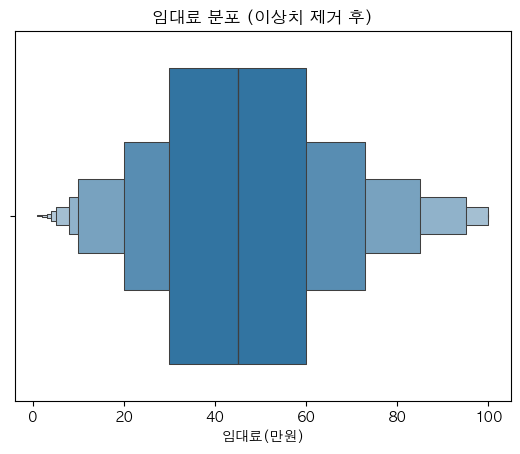

In [38]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

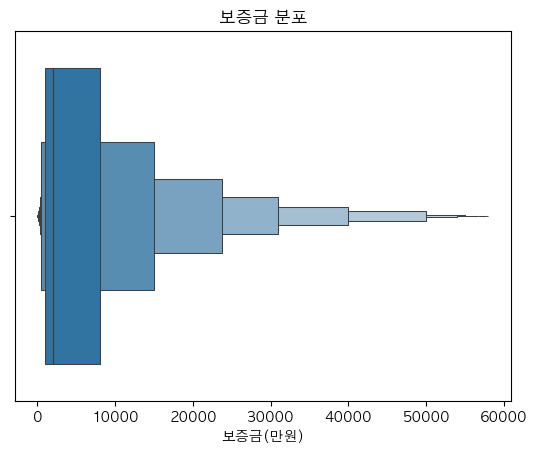

In [39]:
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

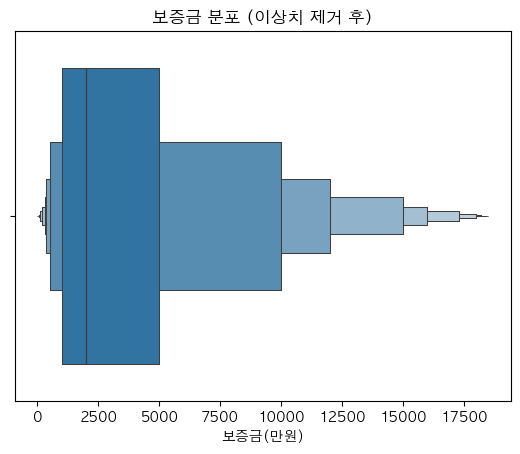

In [40]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

# Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [42]:
# '임대면적'이 0 또는 결측치(NaN)인 경우를 대비하여 에러를 방지합니다.
# 0으로 나누는 것을 방지하기 위해, 면적이 0인 경우는 일단 그대로 둡니다.
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 계산 결과가 무한대(inf)이거나 숫자가 아닌 경우(NaN)는 분석에 방해가 되므로 제거합니다.
# 예를 들어, 임대료는 있는데 면적이 0인 경우 무한대가 될 수 있습니다.
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
     임대면적  임대료(만원)  단위면적당_월세
3   16.13       24  1.487911
10  15.84        5  0.315657
13  28.80       60  2.083333
14  28.80       10  0.347222
15  28.80       50  1.736111


### 대학가 컬럼 생성

In [65]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. 먼저 '대학가'라는 이름의 빈 컬럼을 만듭니다.
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의합니다.
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 반복문을 사용하여 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여합니다.
for univ_name, dong_list in univ_dong_map.items():
    # '법정동명' 컬럼의 값이 dong_list에 포함되어 있으면 True인 마스크(mask)를 생성
    mask = df['법정동명'].isin(dong_list)
    # 해당 마스크가 True인 행의 '대학가' 컬럼에 대학 이름을 할당
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 이름이 할당된 행들만 필터링하여 최종 분석용 데이터프레임을 만듭니다.
#    df_combined['대학가'] != '' 는 '대학가' 컬럼이 비어있지 않은 행만 선택하라는 의미입니다.
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 154581 entries, 173 to 3557662
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      154581 non-null  int64  
 1   자치구명      154581 non-null  object 
 2   법정동명      154581 non-null  object 
 3   전월세구분     154581 non-null  object 
 4   임대면적      154581 non-null  float64
 5   보증금(만원)   154581 non-null  int64  
 6   임대료(만원)   154581 non-null  int64  
 7   건물용도      154581 non-null  object 
 8   단위면적당_월세  154581 non-null  float64
 9   대학가       154581 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 13.0+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      108857
서울시립대     23370
홍익대       11703
서울교대      10651
Name: count, dtype: int64

--- 최종 데이터 샘플 (상위 5개) ---
    자치구명 법정동명  대학가  단위면적당_월세
173  관악구  신림동  서울대  2.217295
177  관악구  신림동  서울대  0.240674
178  관악구  신림동  서울대  0.060168
179  관악구 

# EDA

### 대학가별 단위면적당 월세 분포 확인

In [68]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      108857
서울시립대     23370
홍익대       11703
서울교대      10651
Name: count, dtype: int64


In [69]:
# '단위면적당_월세'의 기술 통계량을 확인합니다.
print(df_analysis['단위면적당_월세'].describe())

count    154581.000000
mean          1.846485
std           1.061173
min           0.014215
25%           1.010101
50%           1.757576
75%           2.500000
max           9.433962
Name: 단위면적당_월세, dtype: float64


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_52611/994774853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='대학가', y='단위면적당_월세', data=df_analysis, palette='Set2')


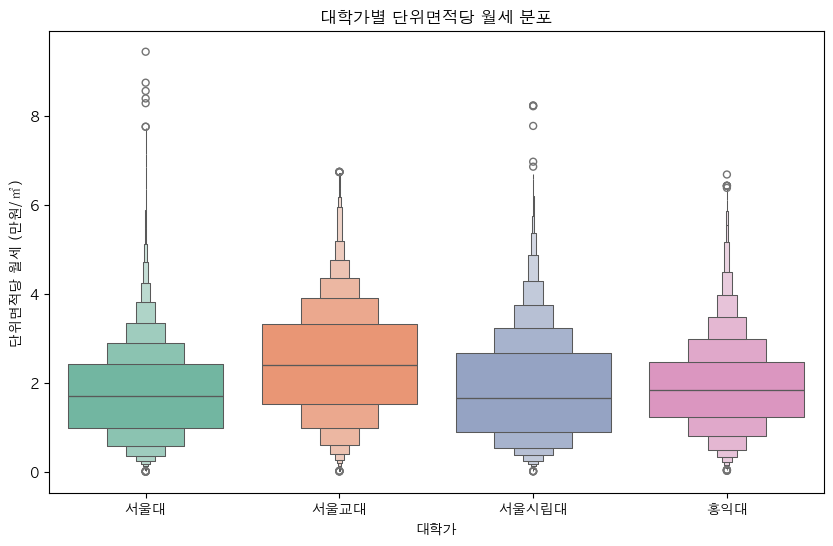

In [67]:
# plotting
plt.figure(figsize=(10, 6))
sns.boxenplot(x='대학가', y='단위면적당_월세', data=df_analysis, palette='Set2')
plt.title('대학가별 단위면적당 월세 분포')
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 연도별 대학가 단위면적당 월세 변화 분석

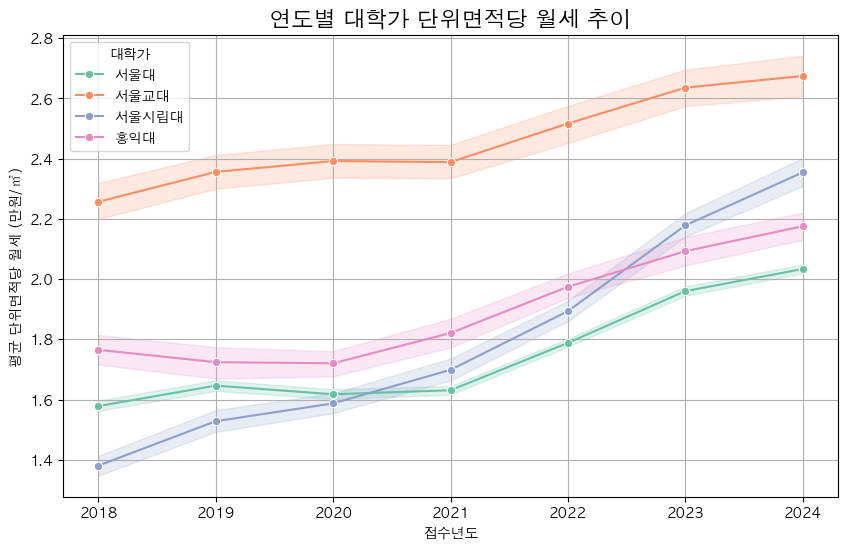

In [91]:
plt.figure(figsize=(10, 6))
# 연도별, 대학가별 단위면적당 월세의 평균을 계산하여 라인 플롯으로 그립니다.
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette='Set2', marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_52611/2377632099.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette='Set2')


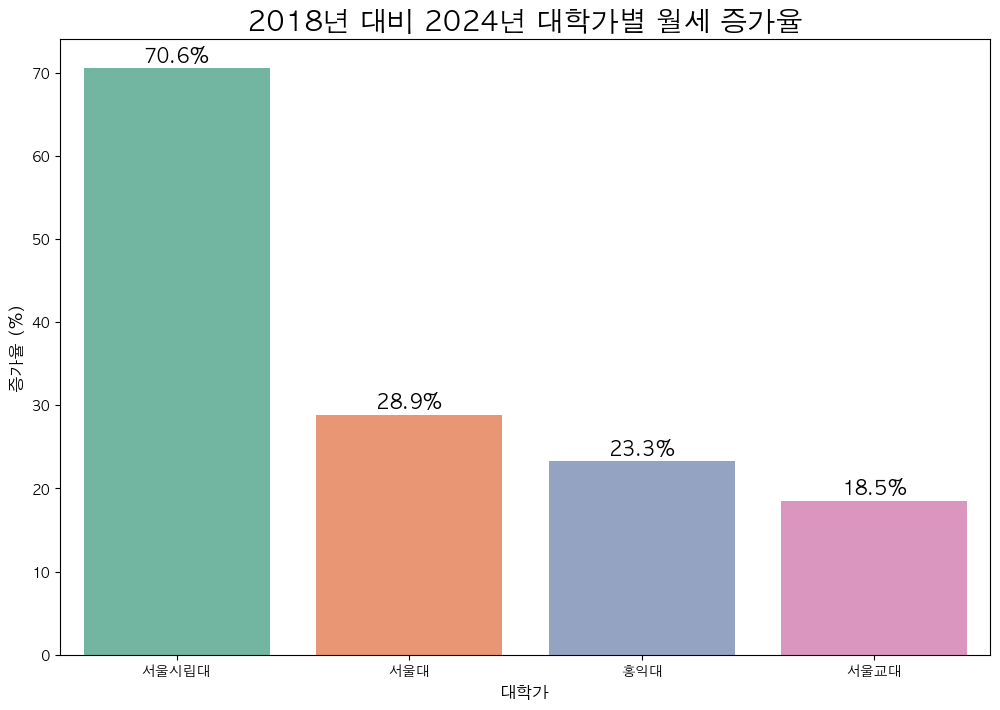

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# (이전 코드 실행으로 df_analysis가 준비되었다고 가정)

# --- 1. 증가율 계산 (이전과 동일) ---
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# --- 2. 정렬된 막대그래프 시각화 ---
# 증가율이 높은 순으로 데이터를 정렬합니다.
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# 막대그래프 생성
# x축에는 대학가 이름, y축에는 증가율 값을 넣습니다.
# order 옵션을 사용하여 정렬된 순서대로 막대를 그립니다.
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette='Set2')

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0) # x축 레이블 회전 방지

# 각 막대 위에 정확한 수치를 텍스트로 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트 (소수점 첫째 자리까지)
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                # 글자 크기 증가

# 그래프 보여주기
plt.show()